In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

calendar = pd.read_csv("../data/calendar.csv", parse_dates=["date"])
transactions = pd.read_csv("../data/transactions.csv", parse_dates=["purchase_date"])
customers = pd.read_csv("../data/customers.csv", parse_dates=["signup_date"])

transactions.head()



,transaction_id,customer_id,purchase_date,subtotal,discount_used,discount_percent,total_spent
0,1,1,2025-11-11,83.67,0,0.0,83.67
1,2,1,2025-12-12,63.55,0,0.0,63.55
2,3,1,2026-01-30,30.88,0,0.0,30.88
3,4,1,2026-02-11,106.98,0,0.0,106.98
4,5,1,2026-04-05,117.22,1,0.3,81.67


In [2]:
transactions = transactions.merge(
    calendar,
    left_on="purchase_date",
    right_on="date",
    how="left"
)

transactions.head()

,transaction_id,customer_id,purchase_date,subtotal,discount_used,discount_percent,total_spent,date,season_number,season_phase,is_season2
0,1,1,2025-11-11,83.67,0,0.0,83.67,2025-11-11,2,regular,True
1,2,1,2025-12-12,63.55,0,0.0,63.55,2025-12-12,2,regular,True
2,3,1,2026-01-30,30.88,0,0.0,30.88,2026-01-30,2,regular,True
3,4,1,2026-02-11,106.98,0,0.0,106.98,2026-02-11,2,regular,True
4,5,1,2026-04-05,117.22,1,0.3,81.67,2026-04-05,2,regular,True


In [3]:
transactions.groupby("season_phase")["total_spent"].sum()

season_phase
offseason     484758.64
playoff      1329384.38
regular      1710928.44
Name: total_spent, dtype: float64

In [4]:
transactions.groupby("season_number")["total_spent"].sum()

season_number
1     724696.00
2    2800375.46
Name: total_spent, dtype: float64

In [5]:
phase_daily = transactions.groupby("season_phase")["total_spent"].sum() / \
              calendar.groupby("season_phase")["date"].count()

phase_daily

season_phase
offseason     2265.227290
playoff      10896.593279
regular       4342.457970
dtype: float64

In [6]:
import pandas as pd

snapshot_dates = pd.date_range(
    start="2024-11-01",
    end="2025-09-01",
    freq="MS"   # Month Start
)

snapshot_dates

DatetimeIndex(['2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01',
               '2025-07-01', '2025-08-01', '2025-09-01'],
              dtype='datetime64[us]', freq='MS')

In [7]:
snapshot_date = pd.Timestamp("2025-04-01")

transactions_before = transactions[
    transactions["purchase_date"] < snapshot_date
]

eligible_customers = transactions_before["customer_id"].unique()

len(eligible_customers)

855

In [8]:
last_purchase = (
    transactions_before
    .groupby("customer_id")["purchase_date"]
    .max()
    .reset_index()
)

last_purchase["recency_days"] = (
    snapshot_date - last_purchase["purchase_date"]
).dt.days

last_purchase.head()

,customer_id,purchase_date,recency_days
0,2,2025-03-31,1
1,5,2025-03-30,2
2,15,2025-03-11,21
3,19,2025-03-26,6
4,29,2025-03-31,1


In [9]:
last_purchase["recency_days"].describe()

count    855.000000
mean      31.956725
std       31.210388
min        1.000000
25%        9.000000
50%       22.000000
75%       43.500000
max      168.000000
Name: recency_days, dtype: float64

In [10]:
window_start = snapshot_date - pd.Timedelta(days=180)

transactions_180 = transactions[
    (transactions["purchase_date"] >= window_start) &
    (transactions["purchase_date"] < snapshot_date)
]

frequency_180 = (
    transactions_180
    .groupby("customer_id")
    .size()
    .reset_index(name="frequency_180d")
)

frequency_180.head()

,customer_id,frequency_180d
0,2,2
1,5,11
2,15,12
3,19,2
4,29,4


In [11]:
len(frequency_180)

855

In [12]:
monetary_180 = (
    transactions_180
    .groupby("customer_id")["total_spent"]
    .sum()
    .reset_index(name="monetary_180d")
)

monetary_180.head()

,customer_id,monetary_180d
0,2,115.17
1,5,1409.97
2,15,1401.53
3,19,123.52
4,29,304.61


In [13]:
monetary_180["monetary_180d"].describe()

count     855.000000
mean      256.260035
std       288.411222
min         6.330000
25%        75.750000
50%       149.270000
75%       295.750000
max      1634.360000
Name: monetary_180d, dtype: float64

In [14]:
discount_180 = (
    transactions_180
    .groupby("customer_id")["discount_used"]
    .mean()
    .reset_index(name="discount_rate_180d")
)

discount_180.head()

,customer_id,discount_rate_180d
0,2,0.000000
1,5,0.181818
2,15,0.333333
3,19,0.500000
4,29,0.750000


In [15]:
discount_180["discount_rate_180d"].describe()

count    855.000000
mean       0.390853
std        0.378596
min        0.000000
25%        0.000000
50%        0.333333
75%        0.666667
max        1.000000
Name: discount_rate_180d, dtype: float64

In [16]:
future_start = snapshot_date
future_end = snapshot_date + pd.Timedelta(days=90)

transactions_future = transactions[
    (transactions["purchase_date"] >= future_start) &
    (transactions["purchase_date"] < future_end)
]

transactions_future.head()

,transaction_id,customer_id,purchase_date,subtotal,discount_used,discount_percent,total_spent,date,season_number,season_phase,is_season2
12,13,2,2025-04-14,98.72,0,0.0,98.72,2025-04-14,1,regular,False
13,14,2,2025-06-06,55.41,0,0.0,55.41,2025-06-06,1,playoff,False
14,15,2,2025-06-09,82.86,0,0.0,82.86,2025-06-09,1,playoff,False
27,28,3,2025-04-07,52.51,0,0.0,52.51,2025-04-07,1,regular,False
28,29,3,2025-05-22,64.09,0,0.0,64.09,2025-05-22,1,playoff,False


In [17]:
len(transactions_future)

4784

In [18]:
# Customers who purchased in next 90 days
future_buyers = transactions_future["customer_id"].unique()

# Create churn label
last_purchase["churn_90d"] = (
    ~last_purchase["customer_id"].isin(future_buyers)
).astype(int)

last_purchase.head()

,customer_id,purchase_date,recency_days,churn_90d
0,2,2025-03-31,1,0
1,5,2025-03-30,2,0
2,15,2025-03-11,21,0
3,19,2025-03-26,6,0
4,29,2025-03-31,1,0


In [19]:
last_purchase["churn_90d"].mean()

np.float64(0.06432748538011696)

In [20]:
snapshot_features = (
    last_purchase[["customer_id", "recency_days", "churn_90d"]]
    .merge(frequency_180, on="customer_id", how="left")
    .merge(monetary_180, on="customer_id", how="left")
    .merge(discount_180, on="customer_id", how="left")
    .merge(customers[["customer_id", "email_signup"]], on="customer_id", how="left")
)

snapshot_features.head()

,customer_id,recency_days,churn_90d,frequency_180d,monetary_180d,discount_rate_180d,email_signup
0,2,1,0,2,115.17,0.000000,0
1,5,2,0,11,1409.97,0.181818,1
2,15,21,0,12,1401.53,0.333333,1
3,19,6,0,2,123.52,0.500000,0
4,29,1,0,4,304.61,0.750000,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Features and target
X = snapshot_features[[
    "recency_days",
    "frequency_180d",
    "monetary_180d",
    "discount_rate_180d",
    "email_signup"
]]

y = snapshot_features["churn_90d"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       240
           1       0.00      0.00      0.00        17

    accuracy                           0.93       257
   macro avg       0.47      0.50      0.48       257
weighted avg       0.87      0.93      0.90       257

ROC AUC: 0.6524509803921569


c:\Users\SUPER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SUPER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SUPER\Desktop\churn-predictor\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [22]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.94      0.65      0.77       240
           1       0.08      0.41      0.13        17

    accuracy                           0.63       257
   macro avg       0.51      0.53      0.45       257
weighted avg       0.88      0.63      0.73       257

ROC AUC: 0.642892156862745


In [23]:
snapshot_rows = []

for snapshot_date in snapshot_dates:

    transactions_before = transactions[
        transactions["purchase_date"] < snapshot_date
    ]

    eligible_customers = transactions_before["customer_id"].unique()

    # Recency
    last_purchase = (
        transactions_before
        .groupby("customer_id")["purchase_date"]
        .max()
        .reset_index()
    )

    last_purchase["recency_days"] = (
        snapshot_date - last_purchase["purchase_date"]
    ).dt.days

    # 180-day window
    window_start = snapshot_date - pd.Timedelta(days=180)

    transactions_180 = transactions[
        (transactions["purchase_date"] >= window_start) &
        (transactions["purchase_date"] < snapshot_date)
    ]

    frequency = (
        transactions_180
        .groupby("customer_id")
        .size()
        .reset_index(name="frequency_180d")
    )

    monetary = (
        transactions_180
        .groupby("customer_id")["total_spent"]
        .sum()
        .reset_index(name="monetary_180d")
    )

    discount = (
        transactions_180
        .groupby("customer_id")["discount_used"]
        .mean()
        .reset_index(name="discount_rate_180d")
    )

    # Churn label
    future_start = snapshot_date
    future_end = snapshot_date + pd.Timedelta(days=90)

    transactions_future = transactions[
        (transactions["purchase_date"] >= future_start) &
        (transactions["purchase_date"] < future_end)
    ]

    future_buyers = transactions_future["customer_id"].unique()

    last_purchase["churn_90d"] = (
        ~last_purchase["customer_id"].isin(future_buyers)
    ).astype(int)

    snapshot = (
        last_purchase[["customer_id","recency_days","churn_90d"]]
        .merge(frequency, on="customer_id", how="left")
        .merge(monetary, on="customer_id", how="left")
        .merge(discount, on="customer_id", how="left")
        .merge(customers[["customer_id","email_signup"]], on="customer_id", how="left")
    )

    snapshot["snapshot_date"] = snapshot_date

    snapshot_rows.append(snapshot)

snapshot_dataset = pd.concat(snapshot_rows)

snapshot_dataset.head()

,customer_id,recency_days,churn_90d,frequency_180d,monetary_180d,discount_rate_180d,email_signup,snapshot_date
0,31,2,0,1.0,127.25,0.0,1,2024-11-01
1,32,3,0,1.0,77.59,1.0,1,2024-11-01
2,122,14,0,1.0,75.80,0.0,1,2024-11-01
3,150,9,0,2.0,269.36,0.0,1,2024-11-01
4,219,13,0,1.0,81.09,1.0,1,2024-11-01


In [25]:
snapshot_dataset.shape

(10196, 8)

In [26]:
snapshot_dataset["churn_90d"].mean()

np.float64(0.2682424480188309)

In [28]:
snapshot_dataset = snapshot_dataset.fillna(0)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Features
X = snapshot_dataset[
    ["recency_days","frequency_180d","monetary_180d","discount_rate_180d","email_signup"]
]

# Target
y = snapshot_dataset["churn_90d"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# Evaluation
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.73      0.98      0.84      2238
           1       0.40      0.03      0.06       821

    accuracy                           0.73      3059
   macro avg       0.57      0.51      0.45      3059
weighted avg       0.65      0.73      0.63      3059

ROC AUC: 0.6777581667118392


In [31]:
import numpy as np
from sklearn.metrics import classification_report

threshold = 0.30
y_pred_adj = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2238
           1       0.39      0.60      0.47       821

    accuracy                           0.64      3059
   macro avg       0.60      0.63      0.60      3059
weighted avg       0.70      0.64      0.66      3059



In [32]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

feature_importance

frequency_180d        0.388911
discount_rate_180d    0.204262
recency_days          0.004021
monetary_180d        -0.004601
email_signup         -0.201492
dtype: float64

In [33]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

pipe.fit(X_train, y_train)

y_proba_scaled = pipe.predict_proba(X_test)[:, 1]
y_pred_scaled = (y_proba_scaled >= 0.30).astype(int)

print(classification_report(y_test, y_pred_scaled))
print("ROC AUC:", roc_auc_score(y_test, y_proba_scaled))

              precision    recall  f1-score   support

           0       0.82      0.65      0.73      2238
           1       0.39      0.60      0.47       821

    accuracy                           0.64      3059
   macro avg       0.60      0.63      0.60      3059
weighted avg       0.70      0.64      0.66      3059

ROC AUC: 0.6777064631614925


In [34]:
coef_model = pipe.named_steps["logisticregression"]

feature_importance_scaled = pd.Series(
    coef_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

feature_importance_scaled

frequency_180d        1.051056
recency_days          0.144778
discount_rate_180d    0.076455
email_signup         -0.101488
monetary_180d        -1.472514
dtype: float64

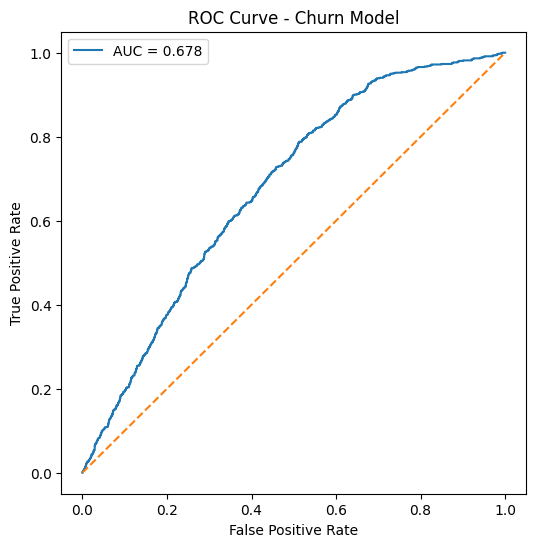

In [35]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba_scaled)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_scaled):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Model")
plt.legend()
plt.show()